# Preprocessing
This notebook runs the full data cleaning and preparation pipeline for modeling.

Covered steps:
- remove errors, duplicates, and outliers
- enforce coordinate and timestamp consistency
- apply GPS noise filtering
- normalize/standardize numeric features
- create stratified train/validation/test splits
- export final clean datasets

## 1) Setup and Data Loading
We import required libraries, define constants, and load the raw dataset.
The output preview confirms the input shape and sample rows before cleaning.

In [3]:
# 1) Imports and setup
from pathlib import Path
import json

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)

TARGET_COLUMN = "target_label"

LABEL_CANONICAL_MAP = {
    "amphi 1": "Amphi 1",
    "amphi 2": "Amphi 2",
    "amphi 3": "Amphi 3",
    "amphi 4": "Amphi 4",
    "amphi 5": "Amphi 5",
    "amphi 6": "Amphi 6",
    "amphi 7": "Amphi 7",
    "amphi 8": "Amphi 8",
    "lab 1": "Amphi 1",
    "lab 2": "Amphi 2",
    "lab 3": "Amphi 3",
    "lab 4": "Amphi 4",
    "lab 5": "Amphi 5",
    "lab 6": "Amphi 6",
    "lab 7": "Amphi 7",
    "lab 8": "Amphi 8",
    "outside": "Outside",
}

project_root = Path("..")
input_path = project_root / "data" / "raw" / "gps_data_v2.csv"
output_dir = project_root / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

raw_df = pd.read_csv(input_path)
print(f"Raw shape: {raw_df.shape}")
raw_df.head(3)

Raw shape: (8366, 24)


,id,year,section,user,amphitheatre,module,seat_block,seat_row,seat_column,latitude_mean,longitude_mean,accuracy_mean,gps_variance,is_outside,sample_count,raw_gps_readings,collection_metadata,navigator_context,screen_context,network_information,battery_status,timestamp,created_at,device_info
0,2,3,NaN,NaN,Amphi 3,Manual Selection,Center,3.0,6.0,36.687824,2.867150,70.0,0.00,False,0,"[{'latitude': 36.687824, 'longitude': 2.86715,...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Win32', 'user_agent': 'Mozilla/5...","{'avail_width': 1536, 'color_depth': 32, 'avai...","{'rtt_ms': 250, 'save_data': False, 'downlink_...","{'is_charging': False, 'battery_level': 0.96}",2026-03-05 07:28:56.580000+00:00,2026-03-05 07:29:01.758897+00:00,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
1,3,3,NaN,NaN,lab 8,Campus-wide Data,NaN,NaN,NaN,36.688127,2.867512,85.0,0.00,True,0,"[{'latitude': 36.688126994584465, 'longitude':...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Win32', 'user_agent': 'Mozilla/5...","{'avail_width': 1536, 'color_depth': 32, 'avai...","{'rtt_ms': 200, 'save_data': False, 'downlink_...","{'is_charging': False, 'battery_level': 0.76}",2026-03-05 10:00:57.029000+00:00,2026-03-05 10:00:56.927949+00:00,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
2,4,3,NaN,NaN,School entry,Campus-wide Data,NaN,NaN,NaN,36.688729,2.865596,14.6,3.84,True,0,"[{'latitude': 36.6886848, 'longitude': 2.86555...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Linux armv81', 'user_agent': 'Mo...","{'avail_width': 384, 'color_depth': 24, 'avail...","{'rtt_ms': 100, 'save_data': False, 'downlink_...","{'is_charging': False, 'battery_level': 0.77}",2026-03-05 10:15:16.599000+00:00,2026-03-05 10:15:16.067975+00:00,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...


## 2) Utility Functions
These helper functions standardize amphitheatre labels and remove outliers using the IQR method.
They are reused in later steps to keep the pipeline readable and consistent.

In [5]:
# 2) Helper functions

def canonicalize_label(amphitheatre, is_outside):
    label = str(amphitheatre).strip().lower()
    if label in LABEL_CANONICAL_MAP:
        return LABEL_CANONICAL_MAP[label]

    outside_value = str(is_outside).strip().lower()
    if outside_value in {"true", "1", "yes"}:
        return "Outside"

    return "Outside"


def remove_outliers_iqr(df, columns, k=2.0):
    mask = pd.Series(True, index=df.index)
    for col in columns:
        if col not in df.columns:
            continue

        series = pd.to_numeric(df[col], errors="coerce")
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            continue

        lower = q1 - k * iqr
        upper = q3 + k * iqr
        mask &= series.between(lower, upper, inclusive="both")

    return df.loc[mask].copy()


print("Helper functions ready")

Helper functions ready


## 3) Initial Data Quality Check
This section reports baseline quality issues: duplicates, missing critical fields, and noisy label variants.
It gives a clear starting point before applying transformations.

In [6]:
# 3) Initial quality report (errors, duplicates, missing values)
work_df = raw_df.copy()

report = {
    "rows": int(len(work_df)),
    "exact_duplicates": int(work_df.duplicated().sum()),
    "duplicate_ids": int(work_df["id"].duplicated().sum()) if "id" in work_df.columns else None,
    "missing_lat_lon": int(work_df[["latitude_mean", "longitude_mean"]].isna().any(axis=1).sum()),
    "missing_timestamp": int(work_df["timestamp"].isna().sum()) if "timestamp" in work_df.columns else None,
}

print(json.dumps(report, indent=2))
work_df["amphitheatre"].value_counts(dropna=False).head(12)

{
  "rows": 8366,
  "exact_duplicates": 0,
  "duplicate_ids": 0,
  "missing_lat_lon": 0,
  "missing_timestamp": 0
}


amphitheatre
Amphi 2             2565
Amphi 5             1227
Amphi 8              989
Amphi 6              774
Amphi 4              741
Outside              658
Amphi 1              604
Amphi 3              318
Amphi 7              122
Nasro                100
Mdpres end tarek      46
maalma3               33
Name: count, dtype: int64

## 4) Parse Timestamps and Remove Duplicates
We convert timestamps to UTC datetimes, drop duplicate rows/IDs, and remove rows missing essential location/time fields.
This ensures the dataset is temporally valid and uniquely indexed.

In [7]:
# 4) Timestamp parsing + duplicate removal + critical missing-value removal
before = len(work_df)

work_df = work_df.drop_duplicates().copy()
if "timestamp" in work_df.columns:
    work_df["timestamp"] = pd.to_datetime(work_df["timestamp"], errors="coerce", utc=True)
if "created_at" in work_df.columns:
    work_df["created_at"] = pd.to_datetime(work_df["created_at"], errors="coerce", utc=True)

work_df = work_df.dropna(subset=["latitude_mean", "longitude_mean", "timestamp"])
work_df = work_df.sort_values("timestamp")
if "id" in work_df.columns:
    work_df = work_df.drop_duplicates(subset=["id"], keep="last")

print(f"Rows before: {before}")
print(f"Rows after basic cleaning: {len(work_df)}")
print("Timestamp range:", work_df["timestamp"].min(), "->", work_df["timestamp"].max())

Rows before: 8366
Rows after basic cleaning: 8348
Timestamp range: 2026-03-05 07:28:56.580000+00:00 -> 2026-04-20 12:35:26.213000+00:00


## 5) Coordinate Consistency and Label Normalization
Numeric GPS fields are coerced to proper types, impossible coordinates are removed, and labels are mapped to canonical classes.
This creates a clean target variable for supervised learning.

In [8]:
# 5) Coordinate/numeric consistency + canonical labels
for col in ["latitude_mean", "longitude_mean", "accuracy_mean", "gps_variance", "sample_count"]:
    if col in work_df.columns:
        work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

work_df = work_df[work_df["latitude_mean"].between(-90, 90)]
work_df = work_df[work_df["longitude_mean"].between(-180, 180)]

work_df[TARGET_COLUMN] = [
    canonicalize_label(amphitheatre, is_outside)
    for amphitheatre, is_outside in zip(work_df.get("amphitheatre", ""), work_df.get("is_outside", ""))
]

print("Rows after coordinate consistency:", len(work_df))
work_df[TARGET_COLUMN].value_counts()

Rows after coordinate consistency: 8348


target_label
Amphi 2    2565
Amphi 5    1227
Outside    1008
Amphi 8    1000
Amphi 6     763
Amphi 4     741
Amphi 1     604
Amphi 3     318
Amphi 7     122
Name: count, dtype: int64

## 6) GPS Noise Filtering
Rows with extreme GPS uncertainty are removed using the 99th percentile thresholds for `accuracy_mean` and `gps_variance`.
This reduces high-noise samples that can destabilize model training.

In [9]:
# 6) Noise filtering (remove worst GPS quality rows)
before = len(work_df)

if "accuracy_mean" in work_df.columns:
    accuracy_cap = work_df["accuracy_mean"].quantile(0.99)
    work_df = work_df[(work_df["accuracy_mean"].isna()) | (work_df["accuracy_mean"] <= accuracy_cap)]
else:
    accuracy_cap = None

if "gps_variance" in work_df.columns:
    variance_cap = work_df["gps_variance"].quantile(0.99)
    work_df = work_df[(work_df["gps_variance"].isna()) | (work_df["gps_variance"] <= variance_cap)]
else:
    variance_cap = None

print(f"Rows before noise filter: {before}")
print(f"Rows after noise filter:  {len(work_df)}")
print(f"accuracy_mean cap (99th pct): {accuracy_cap}")
print(f"gps_variance cap (99th pct): {variance_cap}")

Rows before noise filter: 8348
Rows after noise filter:  8223
accuracy_mean cap (99th pct): 317.114990234375
gps_variance cap (99th pct): 0.0


## 7) Outlier Removal (IQR)
We apply an interquartile-range filter to key spatial and quality features.
This step removes statistical extremes while preserving most valid observations.

In [10]:
# 7) Outlier filtering (IQR)
before = len(work_df)
outlier_cols = ["latitude_mean", "longitude_mean", "accuracy_mean", "gps_variance"]
clean_df = remove_outliers_iqr(work_df, outlier_cols, k=2.0)

print(f"Rows before outlier filter: {before}")
print(f"Rows after outlier filter:  {len(clean_df)}")

Rows before outlier filter: 8223
Rows after outlier filter:  6663


## 8) Class Readiness for Stratification
Classes with fewer than 3 samples are removed to avoid stratified split failures.
The resulting class distribution is printed to verify balance feasibility.

In [11]:
# 8) Class balancing readiness for stratified split
counts = clean_df[TARGET_COLUMN].value_counts()
valid_classes = counts[counts >= 3].index
removed_classes = counts[counts < 3]
clean_df = clean_df[clean_df[TARGET_COLUMN].isin(valid_classes)].reset_index(drop=True)

print("Final cleaned rows:", len(clean_df))
if len(removed_classes) > 0:
    print("Removed classes (<3 samples):")
    print(removed_classes)
else:
    print("No classes removed")

clean_df[TARGET_COLUMN].value_counts()

Final cleaned rows: 6663
No classes removed


target_label
Amphi 2    2258
Amphi 5    1147
Amphi 8     784
Amphi 6     722
Amphi 4     668
Outside     425
Amphi 1     287
Amphi 3     269
Amphi 7     103
Name: count, dtype: int64

## 9) Stratified Train / Validation / Test Split
The cleaned data is split into 70/15/15 partitions with stratification on the target class.
Printed ratios confirm similar class proportions across all splits.

In [12]:
# 9) Stratified train / validation / test split
train_size, val_size, test_size = 0.7, 0.15, 0.15

if not np.isclose(train_size + val_size + test_size, 1.0):
    raise ValueError("train_size + val_size + test_size must equal 1.0")

train_df, temp_df = train_test_split(
    clean_df,
    test_size=(1.0 - train_size),
    stratify=clean_df[TARGET_COLUMN],
    random_state=42,
)
val_ratio_within_temp = val_size / (val_size + test_size)
val_df, test_df = train_test_split(
    temp_df,
    test_size=(1.0 - val_ratio_within_temp),
    stratify=temp_df[TARGET_COLUMN],
    random_state=42,
)

splits = {
    "train": train_df.reset_index(drop=True),
    "val": val_df.reset_index(drop=True),
    "test": test_df.reset_index(drop=True),
}

print({name: len(df) for name, df in splits.items()})
for name, df in splits.items():
    print(f"\n{name.upper()} class distribution:")
    print(df[TARGET_COLUMN].value_counts(normalize=True).round(3))

{'train': 4664, 'val': 999, 'test': 1000}

TRAIN class distribution:
target_label
Amphi 2    0.339
Amphi 5    0.172
Amphi 8    0.118
Amphi 6    0.108
Amphi 4    0.100
Outside    0.064
Amphi 1    0.043
Amphi 3    0.040
Amphi 7    0.015
Name: proportion, dtype: float64

VAL class distribution:
target_label
Amphi 2    0.338
Amphi 5    0.172
Amphi 8    0.117
Amphi 6    0.108
Amphi 4    0.100
Outside    0.064
Amphi 1    0.043
Amphi 3    0.041
Amphi 7    0.016
Name: proportion, dtype: float64

TEST class distribution:
target_label
Amphi 2    0.339
Amphi 5    0.172
Amphi 8    0.118
Amphi 6    0.109
Amphi 4    0.100
Outside    0.064
Amphi 1    0.043
Amphi 3    0.040
Amphi 7    0.015
Name: proportion, dtype: float64


## 10) Standardization
A `StandardScaler` is fit on the training split only, then applied to validation and test.
This avoids data leakage and produces model-ready scaled features.

In [14]:
# 10) Standardization (fit on train only)
numeric_cols = ["latitude_mean", "longitude_mean", "accuracy_mean", "gps_variance", "sample_count"]
numeric_cols = [col for col in numeric_cols if col in splits["train"].columns]

scaled_splits = {name: frame.copy() for name, frame in splits.items()}

scaler = StandardScaler()
scaler.fit(splits["train"][numeric_cols].fillna(0.0))

for split_name in ("train", "val", "test"):
    values = scaler.transform(splits[split_name][numeric_cols].fillna(0.0))
    for idx, col in enumerate(numeric_cols):
        scaled_splits[split_name][f"{col}_scaled"] = values[:, idx]

print("Standardized columns added:")
print([f"{c}_scaled" for c in numeric_cols])
scaled_splits["train"].head(3)

Standardized columns added:
['latitude_mean_scaled', 'longitude_mean_scaled', 'accuracy_mean_scaled', 'gps_variance_scaled', 'sample_count_scaled']


,id,year,section,user,amphitheatre,module,seat_block,seat_row,seat_column,latitude_mean,longitude_mean,accuracy_mean,gps_variance,is_outside,sample_count,raw_gps_readings,collection_metadata,navigator_context,screen_context,network_information,battery_status,timestamp,created_at,device_info,target_label,latitude_mean_scaled,longitude_mean_scaled,accuracy_mean_scaled,gps_variance_scaled,sample_count_scaled
0,7035,2,NaN,NaN,Amphi 4,Computer Architecture,Left,1.0,3.0,36.688274,2.866118,7.899,0.0,False,1,[],{},{},{},{},{},2026-04-12 16:09:47.190000+00:00,2026-04-12 16:09:47.851406+00:00,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Amphi 4,-2.208640,-1.475165,-1.392938,0.0,0.046354
1,619,1,NaN,NaN,Amphi 2,Object Oriented Programming,Center,1.0,6.0,36.688346,2.866498,20.000,0.0,False,1,[],{},{},{},{},{},2026-04-08 07:43:31.150000+00:00,2026-04-08 07:43:33.205984+00:00,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Amphi 2,-0.114272,0.292914,0.151644,0.0,0.046354
2,1296,1,NaN,NaN,Amphi 2,Object Oriented Programming,Right,4.0,3.0,36.688340,2.866477,34.320,0.0,False,1,[],{},{},{},{},{},2026-04-08 09:20:39.922000+00:00,2026-04-08 09:20:44.007714+00:00,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,Amphi 2,-0.283928,0.192931,1.979460,0.0,0.046354


## 11) Export Processed Datasets
This step saves cleaned, split, and scaled datasets to `data/processed/`, along with a JSON summary.
These files are the final inputs for feature engineering and modeling notebooks.

In [15]:
# 11) Save all outputs
clean_df.to_csv(output_dir / "gps_data_clean.csv", index=False)
for name, frame in splits.items():
    frame.to_csv(output_dir / f"{name}.csv", index=False)
for name, frame in scaled_splits.items():
    frame.to_csv(output_dir / f"{name}_scaled.csv", index=False)

summary = {
    "rows_cleaned": int(len(clean_df)),
    "class_distribution": clean_df[TARGET_COLUMN].value_counts().to_dict(),
    "split_sizes": {name: int(len(frame)) for name, frame in splits.items()},
}
(output_dir / "preprocessing_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("Saved files:")
print("-", output_dir / "gps_data_clean.csv")
print("-", output_dir / "train.csv")
print("-", output_dir / "val.csv")
print("-", output_dir / "test.csv")
print("-", output_dir / "train_scaled.csv")
print("-", output_dir / "val_scaled.csv")
print("-", output_dir / "test_scaled.csv")
print("-", output_dir / "preprocessing_summary.json")

Saved files:
- ../data/processed/gps_data_clean.csv
- ../data/processed/train.csv
- ../data/processed/val.csv
- ../data/processed/test.csv
- ../data/processed/train_scaled.csv
- ../data/processed/val_scaled.csv
- ../data/processed/test_scaled.csv
- ../data/processed/preprocessing_summary.json


## 12) Final Summary
We display the generated preprocessing summary to verify final row counts, class distribution, and split sizes.

In [16]:
# 12) Final summary result
summary_path = output_dir / "preprocessing_summary.json"
print(summary_path.read_text())

{
  "rows_cleaned": 6663,
  "class_distribution": {
    "Amphi 2": 2258,
    "Amphi 5": 1147,
    "Amphi 8": 784,
    "Amphi 6": 722,
    "Amphi 4": 668,
    "Outside": 425,
    "Amphi 1": 287,
    "Amphi 3": 269,
    "Amphi 7": 103
  },
  "split_sizes": {
    "train": 4664,
    "val": 999,
    "test": 1000
  }
}


## 13) Cleaned Data Visualization Setup
This section recreates your EDA-style visualizations using the cleaned dataset (`clean_df`).
We define plotting styles, amphitheatre footprints, and centroids from cleaned data.

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.patches import Polygon as MplPolygon
import seaborn as sns

AMPHI_COLORS = {
    'Amphi 1': '#2563EB',
    'Amphi 2': '#16A34A',
    'Amphi 3': '#7C3AED',
    'Amphi 4': '#DC2626',
    'Amphi 5': '#0891B2',
    'Amphi 6': '#D97706',
    'Amphi 7': '#BE185D',
    'Amphi 8': '#065F46',
    'Outside': '#6B7280',
}

# Approximate architectural footprints (same layout used in EDA).
FOOTPRINTS = {
    'Amphi 4/8': np.array([
        (2.86588, 36.68800), (2.86602, 36.68800),
        (2.86605, 36.68818), (2.86590, 36.68817),
    ]),
    'Amphi 3/7': np.array([
        (2.86610, 36.68800), (2.86625, 36.68800),
        (2.86628, 36.68819), (2.86613, 36.68818),
    ]),
    'Amphi 2/6': np.array([
        (2.86633, 36.68800), (2.86650, 36.68800),
        (2.86655, 36.68821), (2.86638, 36.68820),
    ]),
    'Amphi 1/5': np.array([
        (2.86658, 36.68805), (2.86675, 36.68806),
        (2.86680, 36.68825), (2.86663, 36.68823),
    ]),
}

FP_FILL = {
    'Amphi 1/5': '#BFDBFE',
    'Amphi 2/6': '#BBF7D0',
    'Amphi 3/7': '#DDD6FE',
    'Amphi 4/8': '#FECACA',
}
FP_EDGE = {
    'Amphi 1/5': '#1D4ED8',
    'Amphi 2/6': '#15803D',
    'Amphi 3/7': '#6D28D9',
    'Amphi 4/8': '#B91C1C',
}
GPS_COLOR_2D = {lbl: AMPHI_COLORS[lbl] for lbl in AMPHI_COLORS}

centroids_clean = (
    clean_df[clean_df[TARGET_COLUMN].str.startswith('Amphi', na=False)]
    .groupby(TARGET_COLUMN)[['latitude_mean', 'longitude_mean']]
    .mean()
    .rename(columns={'latitude_mean': 'centroid_lat', 'longitude_mean': 'centroid_lon'})
)

print('Visualization setup ready.')
centroids_clean

Visualization setup ready.


,centroid_lat,centroid_lon
target_label,,
Amphi 1,36.688395,2.866701
Amphi 2,36.688353,2.866493
Amphi 3,36.688389,2.866236
Amphi 4,36.688306,2.866124
Amphi 5,36.688361,2.866690
Amphi 6,36.688351,2.866478
Amphi 7,36.688358,2.866283
Amphi 8,36.688335,2.866115


## 14) Code 1 on Cleaned Data: Footprints + GPS Scatter
This reproduces your 2D footprint plot using cleaned labels and cleaned centroids.
The figure is saved to `results/amphi_footprints_2d_cleaned.png`.

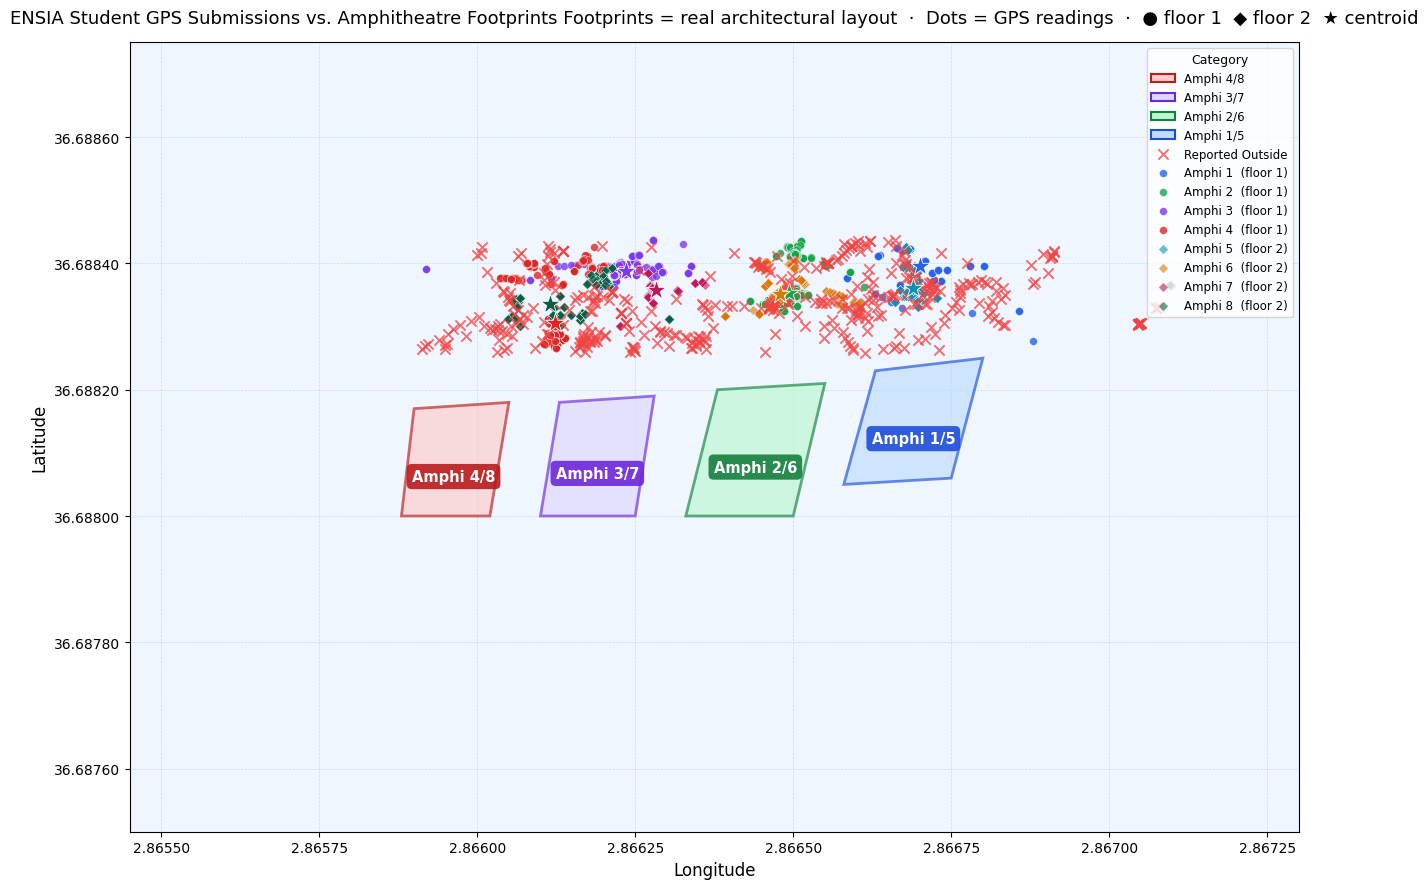

Saved: ../results/amphi_footprints_2d_cleaned.png


In [19]:
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('#EFF6FF')

for name, pts in FOOTPRINTS.items():
    poly = MplPolygon(
        pts,
        closed=True,
        facecolor=FP_FILL[name],
        edgecolor=FP_EDGE[name],
        linewidth=2.0,
        alpha=0.65,
        zorder=2,
    )
    ax.add_patch(poly)
    cx = pts[:, 0].mean()
    cy = pts[:, 1].mean() - 0.000025
    ax.text(
        cx,
        cy,
        name,
        ha='center',
        va='center',
        fontsize=10.5,
        fontweight='bold',
        color='white',
        bbox=dict(facecolor=FP_EDGE[name], edgecolor='none', boxstyle='round,pad=0.35', alpha=0.90),
        zorder=6,
    )

out_df = clean_df[clean_df[TARGET_COLUMN] == 'Outside']
ax.scatter(
    out_df['longitude_mean'],
    out_df['latitude_mean'],
    c='#EF4444',
    marker='x',
    s=55,
    linewidths=1.4,
    label='Reported Outside',
    zorder=4,
    alpha=0.75,
)

FLOOR = {f'Amphi {i}': 1 for i in range(1, 5)}
FLOOR.update({f'Amphi {i}': 2 for i in range(5, 9)})

for lbl in [f'Amphi {i}' for i in range(1, 9)]:
    sub = clean_df[clean_df[TARGET_COLUMN] == lbl]
    if sub.empty:
        continue
    mk = 'o' if FLOOR[lbl] == 1 else 'D'
    size = 32 if FLOOR[lbl] == 1 else 24
    alpha = 0.80 if FLOOR[lbl] == 1 else 0.60
    ax.scatter(
        sub['longitude_mean'],
        sub['latitude_mean'],
        c=GPS_COLOR_2D[lbl],
        marker=mk,
        s=size,
        alpha=alpha,
        label=f'{lbl}  (floor {FLOOR[lbl]})',
        edgecolors='white',
        linewidths=0.3,
        zorder=3,
    )

for lbl, row in centroids_clean.iterrows():
    ax.scatter(
        row['centroid_lon'],
        row['centroid_lat'],
        marker='*',
        s=220,
        c=GPS_COLOR_2D.get(lbl, '#111827'),
        edgecolors='white',
        linewidths=0.6,
        zorder=8,
    )

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(
    'ENSIA Student GPS Submissions vs. Amphitheatre Footprints '
    'Footprints = real architectural layout  ·  Dots = GPS readings  '
    '·  ● floor 1  ◆ floor 2  ★ centroid',
    fontsize=13,
    pad=14,
)
ax.set_xlim(2.86545, 2.86730)
ax.set_ylim(36.68750, 36.68875)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, color='#93C5FD')

fp_handles = [
    mpatches.Patch(facecolor=FP_FILL[n], edgecolor=FP_EDGE[n], linewidth=1.5, label=n)
    for n in FOOTPRINTS
]
ax.legend(
    handles=fp_handles + ax.get_legend_handles_labels()[0],
    loc='upper right',
    fontsize=8.5,
    ncol=1,
    title='Category',
    title_fontsize=9,
)

plt.tight_layout()
plt.savefig('../results/amphi_footprints_2d_cleaned.png', dpi=140, bbox_inches='tight')
plt.show()

print('Saved: ../results/amphi_footprints_2d_cleaned.png')

## 15) Code 2 on Cleaned Data: Per-Class Facets + KDE
This reproduces the per-class facet visualization on cleaned data.
The figure is saved to `results/gps_facets_cleaned.png`.

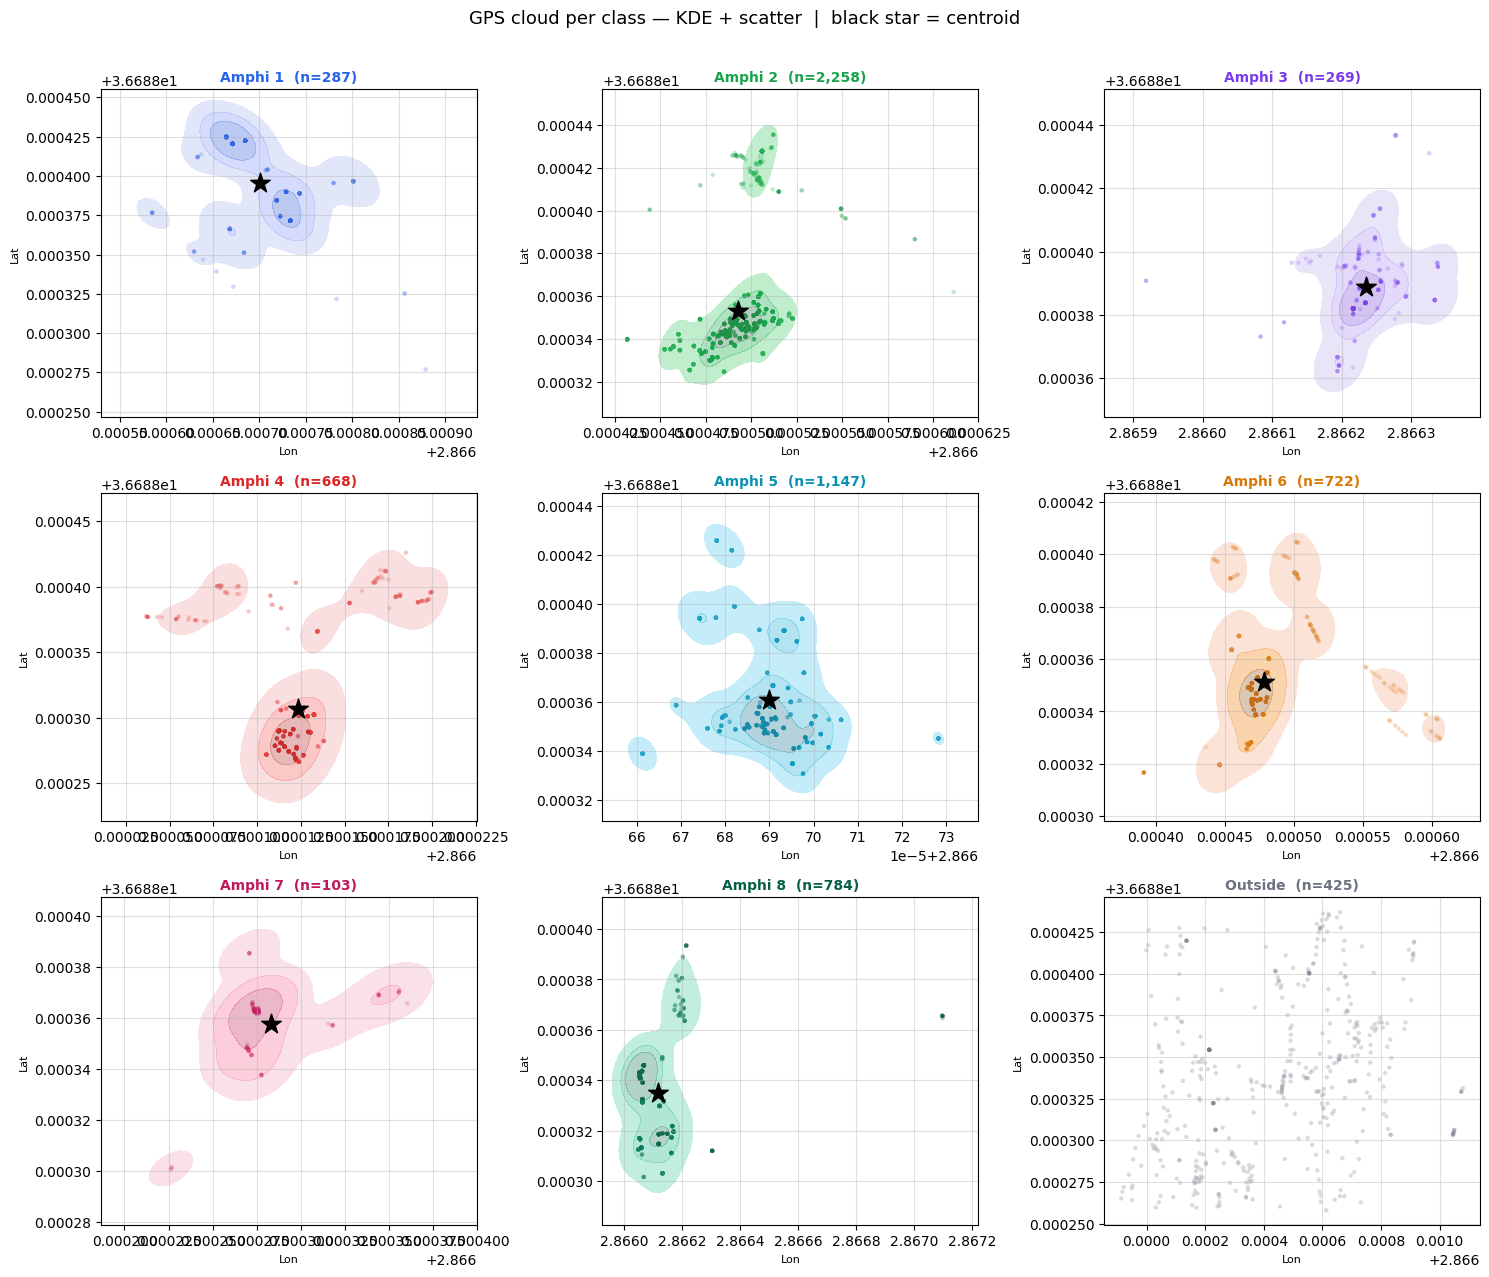

Saved: ../results/gps_facets_cleaned.png


In [20]:
label_order_amphi = [f'Amphi {i}' for i in range(1, 9)] + ['Outside']
cols = 3
rows_n = (len(label_order_amphi) + cols - 1) // cols

fig, axes = plt.subplots(rows_n, cols, figsize=(15, rows_n * 4.2))
axes = axes.flatten()

for i, lbl in enumerate(label_order_amphi):
    sub = clean_df[clean_df[TARGET_COLUMN] == lbl]
    c = AMPHI_COLORS[lbl]
    axes[i].scatter(
        sub['longitude_mean'],
        sub['latitude_mean'],
        color=c,
        alpha=0.25,
        s=10,
        edgecolors='none',
    )
    if lbl != 'Outside' and len(sub) > 15:
        try:
            sns.kdeplot(
                data=sub,
                x='longitude_mean',
                y='latitude_mean',
                fill=True,
                thresh=0.1,
                levels=4,
                color=c,
                alpha=0.35,
                ax=axes[i],
            )
        except Exception:
            pass

    if lbl in centroids_clean.index:
        axes[i].scatter(
            centroids_clean.loc[lbl, 'centroid_lon'],
            centroids_clean.loc[lbl, 'centroid_lat'],
            marker='*',
            s=220,
            color='black',
            zorder=6,
        )

    n_pts = len(sub)
    axes[i].set_title(f'{lbl}  (n={n_pts:,})', fontsize=10, fontweight='semibold', color=c)
    axes[i].set_xlabel('Lon', fontsize=8)
    axes[i].set_ylabel('Lat', fontsize=8)
    axes[i].grid(True, alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('GPS cloud per class — KDE + scatter  |  black star = centroid', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/gps_facets_cleaned.png', bbox_inches='tight')
plt.show()

print('Saved: ../results/gps_facets_cleaned.png')